In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
# Calculate Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

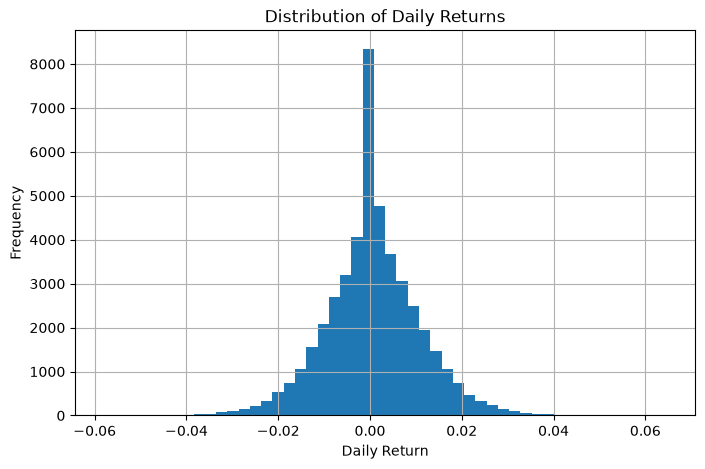

In [6]:
plt.figure(figsize=(8,5))

nav["daily_return"].hist(bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [7]:
import numpy as np

latest = nav.groupby("amfi_code").last().reset_index()

earliest = nav.groupby("amfi_code").first().reset_index()

cagr = earliest[["amfi_code","nav"]].merge(
    latest[["amfi_code","nav"]],
    on="amfi_code",
    suffixes=("_start","_end")
)

years = 1

cagr["CAGR_1Y"] = (
    (cagr["nav_end"]/cagr["nav_start"])**(1/years)-1
)

cagr.head()

,amfi_code,nav_start,nav_end,CAGR_1Y
0,100016,520.4608,583.6113,0.121336
1,100025,26.3169,31.8843,0.211552
2,100033,107.3758,342.0072,2.185142
3,101206,305.0996,773.2939,1.534562
4,101207,38.5736,53.9836,0.399496


In [8]:
rf = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean","std"])

sharpe["Sharpe"] = (
    (sharpe["mean"]*252-rf) /
    (sharpe["std"]*np.sqrt(252))
)

sharpe.sort_values("Sharpe",ascending=False).head()

,mean,std,Sharpe
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101


In [9]:
def max_drawdown(df):

    running_max = df["nav"].cummax()

    drawdown = (df["nav"]-running_max)/running_max

    return drawdown.min()

max_dd = nav.groupby("amfi_code").apply(max_drawdown)

max_dd.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
dtype: float64

In [10]:
rf = 0.065

def sortino(x):
    downside = x[x < 0]

    downside_std = downside.std()

    if downside_std == 0 or np.isnan(downside_std):
        return np.nan

    return (x.mean()*252 - rf) / (downside_std*np.sqrt(252))

sortino_ratio = nav.groupby("amfi_code")["daily_return"].apply(sortino)

sortino_ratio.head()

amfi_code
100016   -0.351047
100025   -0.941821
100033    1.829134
101206    1.799563
101207    0.276644
Name: daily_return, dtype: float64

In [11]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [14]:
print(nav.dtypes)

print("\n-----------------\n")

print(benchmark.dtypes)

amfi_code         int64
date                str
nav             float64
daily_return    float64
dtype: object

-----------------

date                datetime64[us]
index_name                     str
close_value                float64
benchmark_return           float64
dtype: object


In [15]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [16]:
print(nav["date"].dtype)
print(benchmark["date"].dtype)

datetime64[us]
datetime64[us]


In [17]:
merged = pd.merge(
    nav,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,NaN
2,100016,2022-01-03,520.4608,NaN,NaN
3,100016,2022-01-03,520.4608,NaN,NaN
4,100016,2022-01-03,520.4608,NaN,NaN


In [18]:
print(nav["daily_return"].notna().sum())
print(benchmark["benchmark_return"].notna().sum())

45960
8043


In [19]:
merged = merged.dropna(subset=["daily_return", "benchmark_return"])

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
7,100016,2022-01-04,515.0971,-0.010306,0.019783
8,100016,2022-01-04,515.0971,-0.010306,0.001516
9,100016,2022-01-04,515.0971,-0.010306,0.000044
10,100016,2022-01-04,515.0971,-0.010306,-0.013540
11,100016,2022-01-04,515.0971,-0.010306,0.011253


In [20]:
print(merged.shape)

(321720, 5)


In [21]:
alpha_beta = []

for code in merged["amfi_code"].unique():

    df = merged[merged["amfi_code"] == code]

    if len(df) > 30:

        beta, alpha, r, p, std = linregress(
            df["benchmark_return"],
            df["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": code,
            "Alpha": alpha * 252,
            "Beta": beta
        })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [22]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [23]:
top5 = nav.groupby("amfi_code")["nav"].last().nlargest(5)

top5

amfi_code
120844    4268.5497
125497    1204.9571
101206     773.2939
149322     606.2349
100016     583.6113
Name: nav, dtype: float64

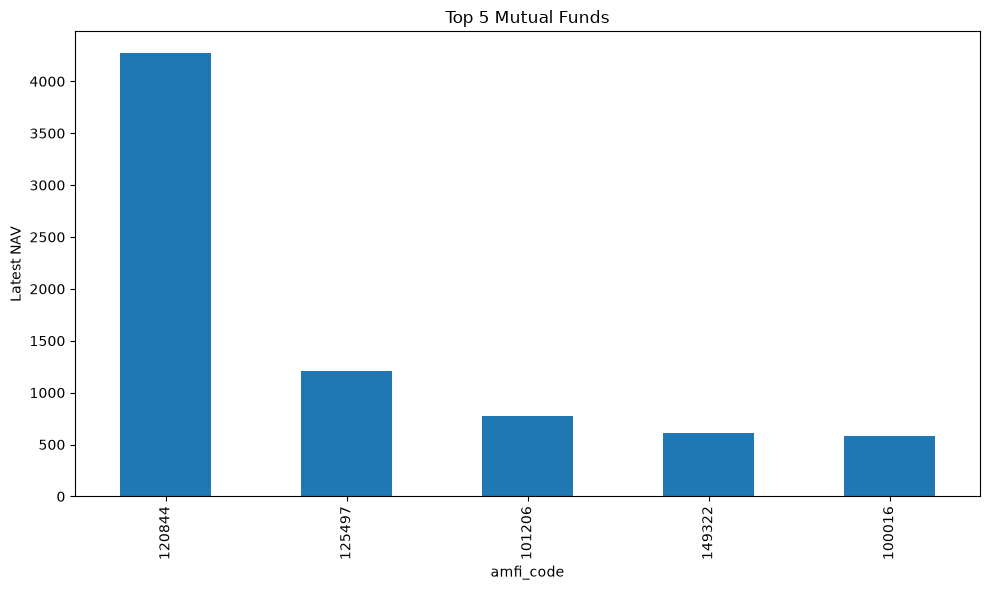

In [24]:
plt.figure(figsize=(10,6))

top5.plot(kind="bar")

plt.title("Top 5 Mutual Funds")
plt.ylabel("Latest NAV")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()

In [27]:
%whos


Variable        Type         Data/Info
--------------------------------------
alpha           float64      0.0011738930950791614
alpha_beta      DataFrame    Shape: (40, 3)
benchmark       DataFrame    Shape: (8050, 4)
beta            float64      0.036666926671328044
cagr            DataFrame    Shape: (40, 4)
code            int64        149324
df              DataFrame    Shape: (8043, 5)
earliest        DataFrame    Shape: (40, 4)
fund_master     DataFrame    Shape: (40, 15)
latest          DataFrame    Shape: (40, 4)
linregress      function     <function linregress at 0x000001412BD66770>
max_dd          Series       Shape: (40,)
max_drawdown    function     <function max_drawdown at 0x0000014169516FB0>
merged          DataFrame    Shape: (321720, 5)
nav             DataFrame    Shape: (46000, 4)
np              module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
p               float64      0.06579401761155457
pd              module       <module 'pandas' from 'c

In [28]:
max_dd = max_dd.reset_index()
max_dd.columns = ["amfi_code", "Max_Drawdown"]

max_dd.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [29]:
cagr.columns

Index(['amfi_code', 'nav_start', 'nav_end', 'CAGR_1Y'], dtype='str')

In [30]:
sharpe.columns

Index(['mean', 'std', 'Sharpe'], dtype='str')

In [31]:
alpha_beta.columns

Index(['amfi_code', 'Alpha', 'Beta'], dtype='str')

In [32]:
max_dd.columns

Index(['amfi_code', 'Max_Drawdown'], dtype='str')

In [33]:
scorecard = (
    cagr
    .merge(sharpe, on="amfi_code")
    .merge(alpha_beta, on="amfi_code")
    .merge(max_dd, on="amfi_code")
)

scorecard.head()

,amfi_code,nav_start,nav_end,CAGR_1Y,mean,std,Sharpe,Alpha,Beta,Max_Drawdown
0,100016,520.4608,583.6113,0.121336,0.000142,0.009164,-0.201517,0.035008,0.004843,-0.247344
1,100025,26.3169,31.8843,0.211552,0.000170,0.002460,-0.567095,0.043330,-0.003422,-0.043083
2,100033,107.3758,342.0072,2.185142,0.001080,0.011929,1.093699,0.268752,0.024097,-0.162172
3,101206,305.0996,773.2939,1.534562,0.000852,0.009177,1.027213,0.214656,-0.000067,-0.112916
4,101207,38.5736,53.9836,0.399496,0.000424,0.016251,0.162661,0.110250,-0.023588,-0.354469


In [35]:
scorecard.columns

Index(['amfi_code', 'nav_start', 'nav_end', 'CAGR_1Y', 'mean', 'std', 'Sharpe',
       'Alpha', 'Beta', 'Max_Drawdown'],
      dtype='str')

In [36]:
# Ranking
scorecard["Return_Rank"] = scorecard["CAGR_1Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["DD_Rank"] = scorecard["Max_Drawdown"].rank(ascending=True)

# Composite Fund Score
scorecard["Fund_Score"] = (
    scorecard["Return_Rank"] * 0.30 +
    scorecard["Sharpe_Rank"] * 0.25 +
    scorecard["Alpha_Rank"] * 0.20 +
    scorecard["DD_Rank"] * 0.10
)

# Lower score = Better fund
scorecard = scorecard.sort_values("Fund_Score")

scorecard.head()

,amfi_code,nav_start,nav_end,CAGR_1Y,mean,std,Sharpe,Alpha,Beta,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,DD_Rank,Fund_Score
25,120505,135.8720,473.7640,2.486841,0.001161,0.012152,1.180101,0.295085,-0.017454,-0.181885,1.0,5.0,3.0,16.0,3.75
36,148569,28.8620,97.7435,2.386581,0.001124,0.011134,1.234930,0.280803,0.017641,-0.163967,4.0,3.0,4.0,20.0,4.75
21,119598,89.8738,309.2050,2.440435,0.001201,0.015837,0.945308,0.303145,-0.003508,-0.287060,2.0,14.0,1.0,5.0,4.80
39,149324,81.6814,279.7511,2.424906,0.001194,0.015648,0.949796,0.295821,0.036667,-0.311719,3.0,13.0,2.0,4.0,4.95
30,120843,49.9131,163.2397,2.270478,0.001082,0.010008,1.306744,0.273211,-0.004370,-0.129740,6.0,2.0,5.0,28.0,6.10


In [37]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

In [38]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)